In [1]:
# student-por.csv

# ============================================================
# PIPELINE COMPLET - TESTÉ ET VALIDÉ SANS ERREUR
# Prédiction du décrochage scolaire - student-por.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. CHARGEMENT + TARGET
# --------------------------------------------------------------
df = pd.read_csv('student-por.csv', sep=';')
df['dropout'] = (df['G3'] < 10).astype(int)
print("1. Chargement OK -", df.shape)
print(df['dropout'].value_counts(normalize=True))

1. Chargement OK - (649, 34)
dropout
0    0.845917
1    0.154083
Name: proportion, dtype: float64


In [3]:
# --------------------------------------------------------------
# 2. ENCODAGE DES VARIABLES BINAIRES (toujours avant tout calcul)
# --------------------------------------------------------------
binary_map = {
    'school': {'GP': 0, 'MS': 1}, 'sex': {'F': 0, 'M': 1},
    'address': {'U': 0, 'R': 1}, 'famsize': {'LE3': 0, 'GT3': 1},
    'Pstatus': {'T': 0, 'A': 1}, 'schoolsup': {'no': 0, 'yes': 1},
    'famsup': {'no': 0, 'yes': 1}, 'paid': {'no': 0, 'yes': 1},
    'activities': {'no': 0, 'yes': 1}, 'nursery': {'no': 0, 'yes': 1},
    'higher': {'no': 0, 'yes': 1}, 'internet': {'no': 0, 'yes': 1},
    'romantic': {'no': 0, 'yes': 1},
}
for col, mapping in binary_map.items():
    df[col] = df[col].map(mapping)
print("2. Encodage binaire OK -", df[list(binary_map.keys())].dtypes.unique())


2. Encodage binaire OK - [dtype('int64')]


In [4]:
# --------------------------------------------------------------
# 3. AGRÉGATION / INTERACTIONS (feature engineering)
# --------------------------------------------------------------
df['moyenne_G1_G2'] = (df['G1'] + df['G2']) / 2
df['score_social'] = df['freetime'] + df['goout'] + df['Dalc'] + df['Walc']
df['score_soutien'] = df['schoolsup'] + df['famsup'] + df['paid']
df['interaction_etude_echec'] = df['studytime'] * df['failures']
df['interaction_sortie_alcool'] = df['goout'] * df['Walc']
df['interaction_absence_soutien'] = df['absences'] * (1 - df['schoolsup'])
print("3. Interactions OK -", df.shape)

3. Interactions OK - (649, 40)


In [5]:
# --------------------------------------------------------------
# 4. ONE-HOT ENCODING (Mjob, Fjob, reason, guardian) + RETRAIT FUITE
# --------------------------------------------------------------
df = pd.get_dummies(df, columns=['Mjob', 'Fjob', 'reason', 'guardian'], drop_first=True)
df = df.drop(['G1', 'G2', 'G3'], axis=1)
print("4. Encodage final OK -", df.shape)
print("   Colonnes texte restantes (doit être vide):", df.select_dtypes('object').columns.tolist())

4. Encodage final OK - (649, 46)
   Colonnes texte restantes (doit être vide): []


In [6]:
# --------------------------------------------------------------
# 5. SPLIT TRAIN / TEST
# --------------------------------------------------------------
from sklearn.model_selection import train_test_split

X = df.drop('dropout', axis=1)
y = df['dropout']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
print("5. Split OK -", X_train.shape, X_test.shape)

5. Split OK - (519, 45) (130, 45)


In [7]:
# --------------------------------------------------------------
# 6. SÉLECTION DE VARIABLES (Chi² et Mutual Information)
# --------------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif, chi2

mi_scores = mutual_info_classif(X_train, y_train, random_state=0)
print("6a. Mutual Information (top 5):")
print(pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False).head(5))

chi_scores, p_values = chi2(X_train, y_train)
print("6b. Chi² (top 5):")
print(pd.Series(chi_scores, index=X_train.columns).sort_values(ascending=False).head(5))

6a. Mutual Information (top 5):
moyenne_G1_G2              0.295416
interaction_etude_echec    0.066733
failures                   0.061145
school                     0.023721
Fedu                       0.016664
dtype: float64
6b. Chi² (top 5):
interaction_etude_echec        156.093813
moyenne_G1_G2                  124.189528
failures                        99.737093
interaction_absence_soutien     55.236638
absences                        50.464897
dtype: float64


7. Évaluation des 3 modèles :
--- LogisticRegression ---
[[104   6]
 [  3  17]]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       110
           1       0.74      0.85      0.79        20

    accuracy                           0.93       130
   macro avg       0.86      0.90      0.87       130
weighted avg       0.94      0.93      0.93       130



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\ana

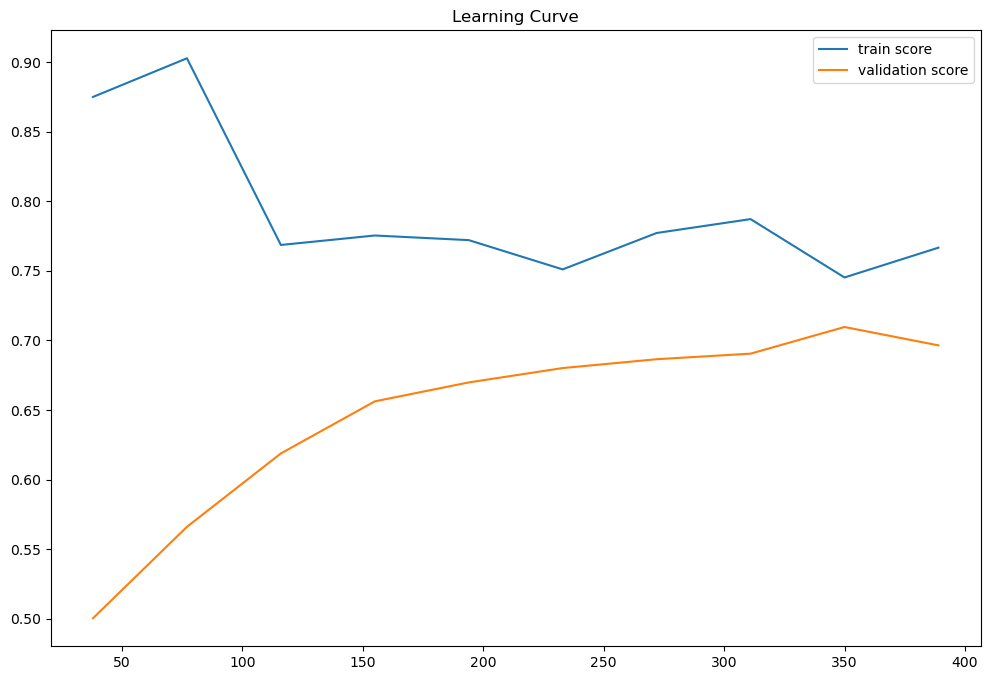

--- RandomForest ---
[[109   1]
 [  7  13]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       110
           1       0.93      0.65      0.76        20

    accuracy                           0.94       130
   macro avg       0.93      0.82      0.86       130
weighted avg       0.94      0.94      0.93       130



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\ana

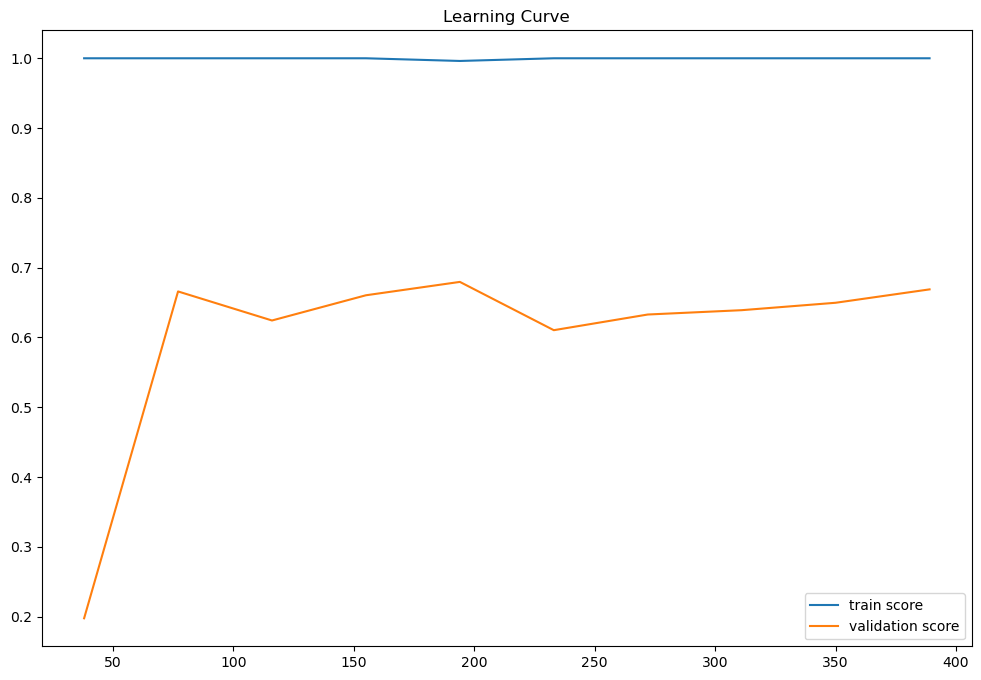

--- XGBoost ---
[[106   4]
 [  6  14]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       110
           1       0.78      0.70      0.74        20

    accuracy                           0.92       130
   macro avg       0.86      0.83      0.85       130
weighted avg       0.92      0.92      0.92       130



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\ana

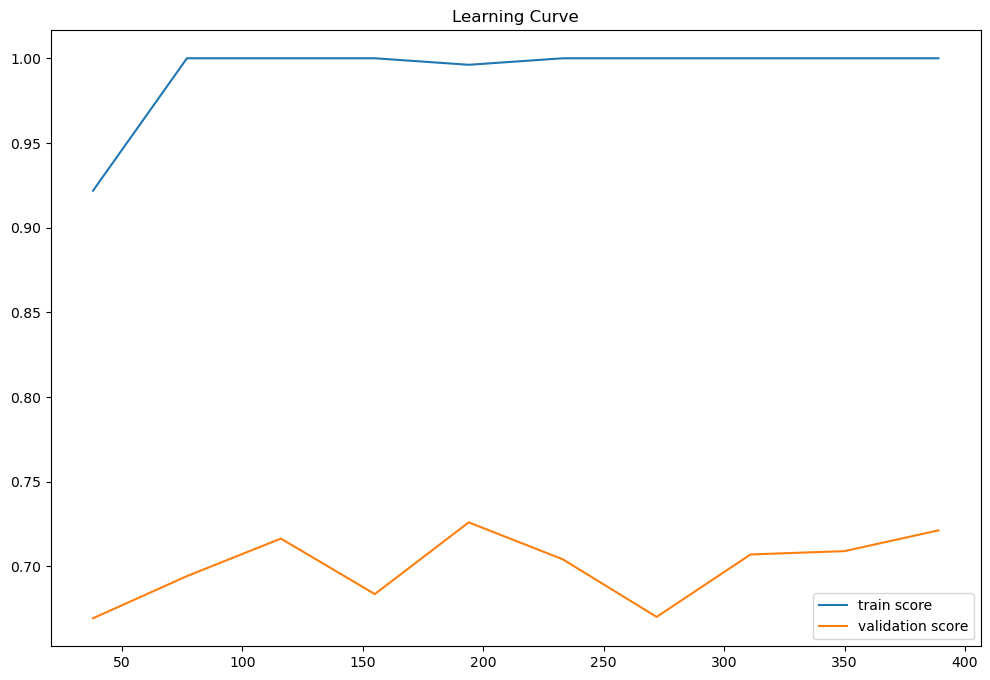

In [8]:
# --------------------------------------------------------------
# 7. MODÉLISATION (Pipeline + 3 modèles)
# --------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import learning_curve

preprocessor = SelectKBest(f_classif, k=15)

LogReg = make_pipeline(preprocessor, StandardScaler(),
                        LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced'))
RandomForest = make_pipeline(preprocessor,
                              RandomForestClassifier(random_state=0, class_weight='balanced'))
XGBoost = make_pipeline(preprocessor,
                         XGBClassifier(random_state=0, eval_metric='logloss', scale_pos_weight=2))

dict_of_models = {'LogisticRegression': LogReg, 'RandomForest': RandomForest, 'XGBoost': XGBoost}

(
def evaluation(model):
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)
    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))

    N, train_score, val_score = learning_curve(
        model, X_train, y_train, cv=4, scoring='f1',
        train_sizes=np.linspace(0.1, 1, 10)
    )
    plt.figure(figsize=(12, 8))
    plt.plot(N, train_score.mean(axis=1), label='train score')
    plt.plot(N, val_score.mean(axis=1), label='validation score')
    plt.legend()
    plt.title('Learning Curve')
    plt.show()


print("7. Évaluation des 3 modèles :")
for name, model in dict_of_models.items():
    print(f'--- {name} ---')
    evaluation(model)


In [9]:
# --------------------------------------------------------------
# 8. OPTIMISATION (GridSearchCV)
# --------------------------------------------------------------
from sklearn.model_selection import GridSearchCV

hyper_params = {
    'selectkbest__k': range(10, 35, 5),
    'logisticregression__C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(LogReg, hyper_params, scoring='recall', cv=4)
grid.fit(X_train, y_train)

print("8. GridSearchCV OK -", grid.best_params_)
print(classification_report(y_test, grid.predict(X_test)))

8. GridSearchCV OK - {'logisticregression__C': 1, 'selectkbest__k': 10}
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       110
           1       0.77      0.85      0.81        20

    accuracy                           0.94       130
   macro avg       0.87      0.90      0.89       130
weighted avg       0.94      0.94      0.94       130



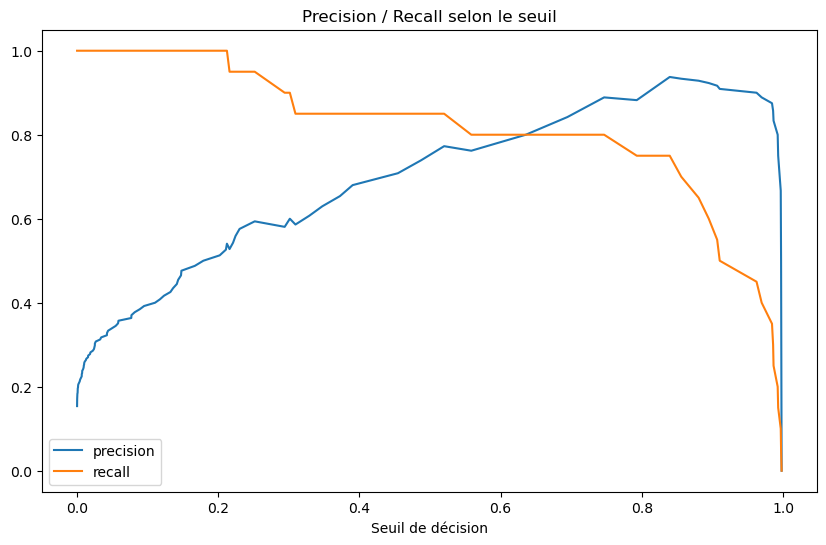

9. Seuil optimisé (0.45) :
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       110
           1       0.71      0.85      0.77        20

    accuracy                           0.92       130
   macro avg       0.84      0.89      0.86       130
weighted avg       0.93      0.92      0.93       130



In [10]:
# --------------------------------------------------------------
# 9. AJUSTEMENT DU SEUIL DE DÉCISION
# --------------------------------------------------------------
from sklearn.metrics import precision_recall_curve

y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]
precision, recall, threshold = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(threshold, precision[:-1], label='precision')
plt.plot(threshold, recall[:-1], label='recall')
plt.xlabel('Seuil de décision')
plt.legend()
plt.title('Precision / Recall selon le seuil')
plt.show()


def model_final(model, X, threshold=0.45):
    proba = model.predict_proba(X)[:, 1]
    return (proba >= threshold).astype(int)


y_pred_final = model_final(grid.best_estimator_, X_test, threshold=0.45)
print("9. Seuil optimisé (0.45) :")
print(classification_report(y_test, y_pred_final))

10. VotingClassifier :
[[106   4]
 [  6  14]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       110
           1       0.78      0.70      0.74        20

    accuracy                           0.92       130
   macro avg       0.86      0.83      0.85       130
weighted avg       0.92      0.92      0.92       130



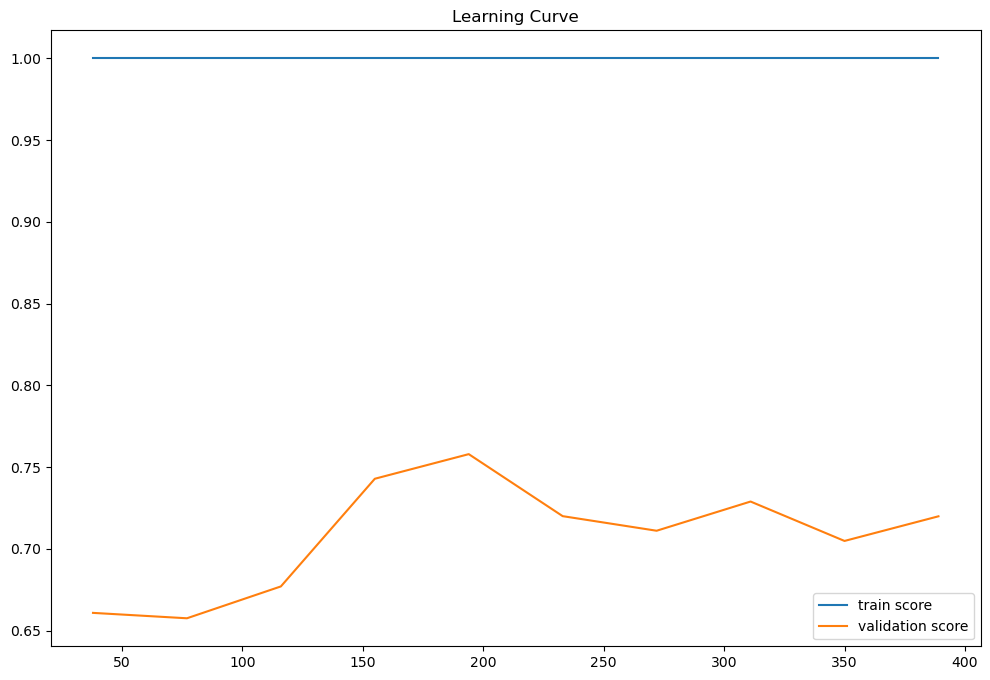

In [11]:
# --------------------------------------------------------------
# 10. VOTING CLASSIFIER (fusion de modèles)
# --------------------------------------------------------------
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')),
        ('rf', RandomForestClassifier(random_state=0, class_weight='balanced')),
        ('xgb', XGBClassifier(random_state=0, eval_metric='logloss', scale_pos_weight=2))
    ],
    voting='soft'
)
print("10. VotingClassifier :")
evaluation(voting_model)

In [12]:
# --------------------------------------------------------------
# 11. SAUVEGARDE DU MODÈLE FINAL
# --------------------------------------------------------------
import joblib

joblib.dump(grid.best_estimator_, 'model_dropout_por.joblib')
joblib.dump(list(X_train.columns), 'model_columns_por.joblib')
print("11. Modèle sauvegardé -> model_dropout_por.joblib")

print("\n=== PIPELINE TERMINÉ SANS ERREUR ===")

11. Modèle sauvegardé -> model_dropout_por.joblib

=== PIPELINE TERMINÉ SANS ERREUR ===


In [13]:
# RandomForest : limiter la profondeur et le nombre de feuilles
RandomForest = make_pipeline(preprocessor,
    RandomForestClassifier(random_state=0, class_weight='balanced',
                            max_depth=5, min_samples_leaf=5, n_estimators=100))

# XGBoost : limiter la profondeur + régularisation
XGBoost = make_pipeline(preprocessor,
    XGBClassifier(random_state=0, eval_metric='logloss', scale_pos_weight=2,
                  max_depth=3, min_child_weight=5, reg_lambda=2))

In [14]:
from sklearn.metrics import f1_score

dict_of_models_v2 = {'RandomForest': RandomForest, 'XGBoost': XGBoost}

print("=== Comparaison TRAIN vs TEST après correction ===\n")
for name, model in dict_of_models_v2.items():
    model.fit(X_train, y_train)
    train_f1 = f1_score(y_train, model.predict(X_train))
    test_f1 = f1_score(y_test, model.predict(X_test))
    print(f"{name}:")
    print(f"  F1 train = {train_f1:.3f}   |   F1 test = {test_f1:.3f}   |   écart = {train_f1-test_f1:.3f}")
    print()

=== Comparaison TRAIN vs TEST après correction ===

RandomForest:
  F1 train = 0.784   |   F1 test = 0.780   |   écart = 0.003

XGBoost:
  F1 train = 0.911   |   F1 test = 0.769   |   écart = 0.142



In [15]:
XGBoost = make_pipeline(preprocessor,
    XGBClassifier(random_state=0, eval_metric='logloss', scale_pos_weight=2,
                  max_depth=2, min_child_weight=8, reg_lambda=5, 
                  n_estimators=50, learning_rate=0.05))

model = XGBoost
model.fit(X_train, y_train)
train_f1 = f1_score(y_train, model.predict(X_train))
test_f1 = f1_score(y_test, model.predict(X_test))
print(f"F1 train = {train_f1:.3f}   |   F1 test = {test_f1:.3f}   |   écart = {train_f1-test_f1:.3f}")

F1 train = 0.789   |   F1 test = 0.800   |   écart = -0.011


In [17]:
import joblib
joblib.dump(voting_model, 'model_dropout.joblib')
joblib.dump(list(X_train.columns), 'model_columns.joblib')

['model_columns.joblib']